In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install lightning pytorch-forecasting torchmetrics


In [ ]:
!pip install lightning pytorch-forecasting torchmetrics scikit-learn

In [ ]:
import pandas as pd
import torch
import lightning.pytorch as pl
from pytorch_forecasting import TimeSeriesDataSet, TemporalFusionTransformer
from pytorch_forecasting.data import GroupNormalizer
from pytorch_forecasting.metrics import SMAPE


In [ ]:
import pandas as pd
import torch
import numpy as np
import lightning.pytorch as pl

from pytorch_forecasting import TimeSeriesDataSet, TemporalFusionTransformer
from pytorch_forecasting.data import GroupNormalizer
from pytorch_forecasting.metrics import SMAPE

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [ ]:
file_path = "/content/drive/MyDrive/supply_chain_demand_forecasting_dataset_2024_2026.csv"
df = pd.read_csv(file_path)
df.head()


,date,sales,day_of_week,month,is_holiday,is_promotion,oil_price
0,2024-01-01,213,0,1,0,0,75.06
1,2024-01-02,224,1,1,0,0,75.16
2,2024-01-03,240,2,1,0,0,75.11
3,2024-01-04,249,3,1,0,0,75.22
4,2024-01-05,239,4,1,0,0,75.25


In [ ]:
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

df["time_idx"] = df.index
df["series_id"] = "0"
for lag in [1, 2, 3, 7, 14, 30]:
    df[f"lag_{lag}"] = df["sales"].shift(lag)
df["rolling_mean_7"] = df["sales"].rolling(7).mean()
df["rolling_std_7"] = df["sales"].rolling(7).std()

df = df.dropna()
scaler = StandardScaler()
df["sales"] = scaler.fit_transform(df[["sales"]])

In [ ]:
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(by="date").reset_index(drop=True)
df["time_idx"] = df.index
df["series_id"] = "0" # Assuming a single time series for simplicity
max_encoder_length = 90
max_prediction_length = 30
training_cutoff = df["time_idx"].max() - max_prediction_length

In [ ]:
max_encoder_length = 150
max_prediction_length = 30

training_cutoff = df["time_idx"].max() - max_prediction_length

training = TimeSeriesDataSet(
    df[df.time_idx <= training_cutoff],
    time_idx="time_idx",
    target="sales",
    group_ids=["series_id"],

    max_encoder_length=max_encoder_length,
    max_prediction_length=max_prediction_length,

    static_categoricals=["series_id"],

    time_varying_known_reals=[
        "time_idx", "day_of_week", "month",
        "is_holiday", "is_promotion", "oil_price"
    ],

    time_varying_unknown_reals=[
        "sales",
        "lag_1","lag_2","lag_3","lag_7","lag_14","lag_30",
        "rolling_mean_7","rolling_std_7"
    ],

    target_normalizer=GroupNormalizer(groups=["series_id"]),
)

validation = TimeSeriesDataSet.from_dataset(training, df, predict=True, stop_randomization=True)

train_loader = training.to_dataloader(train=True, batch_size=256)
val_loader = validation.to_dataloader(train=False, batch_size=256)

In [ ]:
training = TimeSeriesDataSet(
    df[df.time_idx <= training_cutoff],
    time_idx="time_idx",
    target="sales",
    group_ids=["series_id"],

    max_encoder_length=max_encoder_length,
    max_prediction_length=max_prediction_length,

    static_categoricals=["series_id"],

    time_varying_known_reals=[
        "time_idx",
        "day_of_week",
        "month",
        "is_holiday",
        "is_promotion",
        "oil_price"
    ],

    time_varying_unknown_reals=["sales"],

    target_normalizer=GroupNormalizer(groups=["series_id"]),
)

validation = TimeSeriesDataSet.from_dataset(
    training, df, predict=True, stop_randomization=True
)

train_loader = training.to_dataloader(train=True, batch_size=64)
val_loader = validation.to_dataloader(train=False, batch_size=64)

In [ ]:
tft = TemporalFusionTransformer.from_dataset(
    training,
    learning_rate=0.001,
    hidden_size=16,
    attention_head_size=4,
    dropout=0.1,
    hidden_continuous_size=8,
    loss=SMAPE(),
    output_size=1
)


/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.


In [ ]:
trainer = pl.Trainer(
    max_epochs=15,
    accelerator="gpu",
    devices=1,
)


INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


In [ ]:
trainer.fit(
    model=tft,
    train_dataloaders=train_loader,
    val_dataloaders=val_loader
)


INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                               ┃ Type                            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ loss                               │ SMAPE                           │      0 │ train │     0 │
│ 1  │ logging_metrics                    │ ModuleList                      │      0 │ train │     0 │
│ 2  │ input_embeddings                   │ MultiEmbedding                  │      1 │ train │     0 │
│ 3  │ prescalers                         │ ModuleDict                      │    112 │ train │     0 │
│ 4  │ static_variable_selection          │ VariableSelectionNetwork        │     48 │ train │     0 │
│ 5  │ encoder_variable_selection         │ VariableSelectionNetwork        │  4.4 K │ train │     0 │
│ 6  │ decoder_variable_selection         │ VariableSelectionNetwork        │  3.7 K │ train │     0 │
│ 7  │ static_context_variable_selection  │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 8  │ static_context_initial_hidden_lstm │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 9  │ static_context_initial_cell_lstm   │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 10 │ static_context_enrichment          │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 11 │ lstm_encoder                       │ LSTM                            │  2.2 K │ train │     0 │
│ 12 │ lstm_decoder                       │ LSTM                            │  2.2 K │ train │     0 │
│ 13 │ post_lstm_gate_encoder             │ GatedLinearUnit                 │    544 │ train │     0 │
│ 14 │ post_lstm_add_norm_encoder         │ AddNorm                         │     32 │ train │     0 │
│ 15 │ static_enrichment                  │ GatedResidualNetwork            │  1.4 K │ train │     0 │
│ 16 │ multihead_attn                     │ InterpretableMultiHeadAttention │    676 │ train │     0 │
│ 17 │ post_attn_gate_norm                │ GateAddNorm                     │    576 │ train │     0 │
│ 18 │ pos_wise_ff                        │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 19 │ pre_output_gate_norm               │ GateAddNorm                     │    576 │ train │     0 │
│ 20 │ output_layer                       │ Linear                          │     17 │ train │     0 │
└────┴────────────────────────────────────┴─────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 21.8 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 21.8 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 341                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/loops/fit_loop.py:317: The number of training batches 
(14) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if
you want to see logs for the training epoch.

INFO: `Trainer.fit` stopped: `max_epochs=15` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=15` reached.


INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch

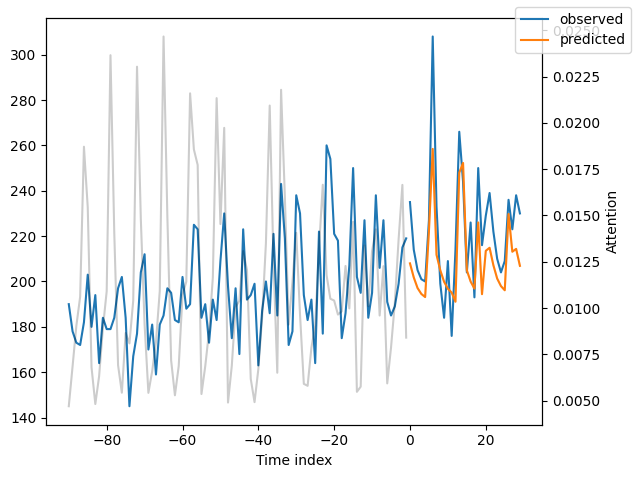

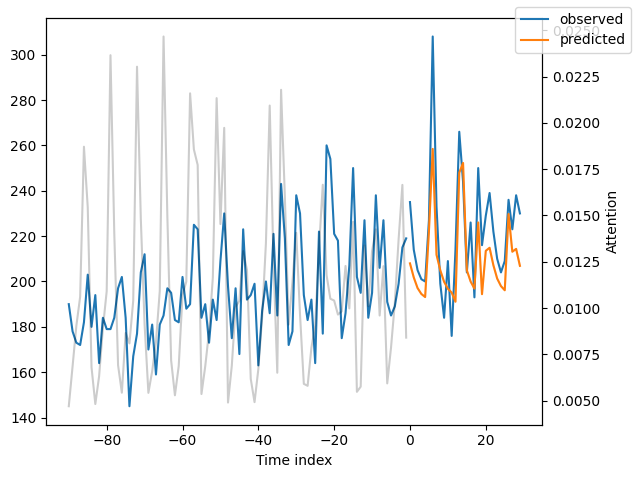

In [ ]:
output = tft.predict(
    val_loader,
    mode="raw",
    return_x=True
)

raw_predictions, x = output[0], output[1]
tft.plot_prediction(x, raw_predictions, idx=0)


In [ ]:
import numpy as np

def create_sequences(data, seq_length=90):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

sales = df["sales"].values
X, y = create_sequences(sales)

X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32)

train_size = int(0.8 * len(X))
X_train, X_val = X[:train_size], X[train_size:]
y_train, y_val = y[:train_size], y[train_size:]


In [ ]:
import torch.nn as nn

class SalesTransformer(nn.Module):
    def __init__(self):
        super().__init__()
        self.embedding = nn.Linear(1, 32)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=32, nhead=4, batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)
        self.fc = nn.Linear(32, 1)

    def forward(self, x):
        x = x.unsqueeze(-1)
        x = self.embedding(x)
        x = self.transformer(x)
        return self.fc(x[:, -1])


In [ ]:
model = SalesTransformer().cuda()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

for epoch in range(10):
    model.train()
    optimizer.zero_grad()

    output = model(X_train.cuda())
    loss = criterion(output.squeeze(), y_train.cuda())

    loss.backward()
    optimizer.step()

    print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")


Epoch 1, Loss: 54361.0039
Epoch 2, Loss: 53272.7344
Epoch 3, Loss: 52783.0586
Epoch 4, Loss: 52586.8242
Epoch 5, Loss: 52505.4297
Epoch 6, Loss: 52472.6562
Epoch 7, Loss: 52458.0820
Epoch 8, Loss: 52447.1680
Epoch 9, Loss: 52436.2773
Epoch 10, Loss: 52418.2539


In [ ]:
from pytorch_forecasting.metrics import QuantileLoss

tft = TemporalFusionTransformer.from_dataset(
    training,
    learning_rate=0.001,
    hidden_size=16,
    attention_head_size=4,
    dropout=0.1,
    hidden_continuous_size=8,
    loss=QuantileLoss(quantiles=[0.1, 0.5, 0.9]),
    output_size=3
)

In [ ]:
output = tft.predict(
    val_loader,
    mode="raw",
    return_x=True
)
raw_predictions, x = output[0], output[1]

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch

In [ ]:
import numpy as np
pred = raw_predictions.prediction.cpu().numpy()
p10 = pred[0, :, 0]
p50 = pred[0, :, 1]
p90 = pred[0, :, 2]
actual = x["decoder_target"][0].cpu().numpy()

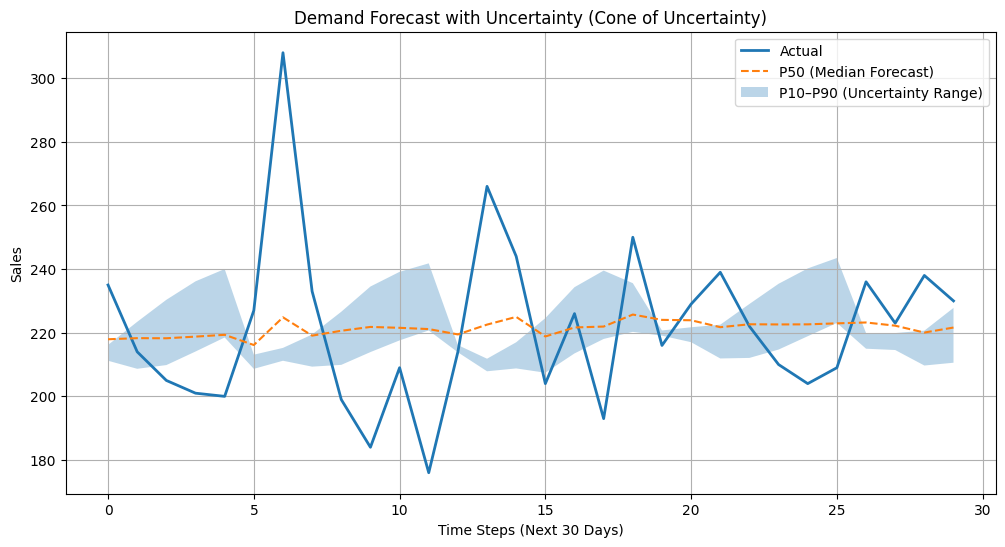

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(actual, label="Actual", linewidth=2)
plt.plot(p50, label="P50 (Median Forecast)", linestyle="--")
plt.fill_between(
    range(len(p50)),
    p10,
    p90,
    alpha=0.3,
    label="P10–P90 (Uncertainty Range)"
)
plt.title("Demand Forecast with Uncertainty (Cone of Uncertainty)")
plt.xlabel("Time Steps (Next 30 Days)")
plt.ylabel("Sales")
plt.legend()
plt.grid()
plt.show()

In [ ]:
from sklearn.metrics import mean_absolute_error
preds = p50
actuals = x["decoder_target"].cpu().numpy().flatten()
mae_tft = mean_absolute_error(actuals, preds)
print("TFT MAE:", mae_tft)

TFT MAE: 18.44085121154785


In [ ]:
from sklearn.metrics import mean_squared_error
import numpy as np

def smape(actual, predicted):
    numerator = np.abs(predicted - actual)
    denominator = (np.abs(actual) + np.abs(predicted)) / 2
    ratio = np.where(denominator == 0, 0, numerator / denominator)
    return np.mean(ratio) * 100

preds = p50
actuals = x["decoder_target"].cpu().numpy().flatten()
rmse_tft = np.sqrt(mean_squared_error(actuals, preds))
smape_tft = smape(actuals, preds)
print("TFT RMSE:", rmse_tft)
print("TFT SMAPE:", smape_tft)

TFT RMSE: 24.553867211083702
TFT SMAPE: 8.23176653544957
